# Feature Engineering in Machine Learning

---

## Notebook Objective

This notebook serves as a hands-on implementation companion to the Feature Engineering module in our ML curriculum. You will learn how to transform raw data into meaningful features that dramatically improve model performance — a skill that separates good ML engineers from great ones.

---

## Learning Outcomes

By the end of this notebook, you will be able to:

- Understand what Feature Engineering is and why it is critical in real-world ML projects
- Implement **manual feature engineering** using NumPy and Pandas
- Build a **Scikit-learn Pipeline** that automates preprocessing and feature transformation
- Apply **StandardScaler**, **MinMaxScaler**, and **PolynomialFeatures** to real data
- Create new features (ratio, sum, difference, product) from existing ones
- Compare model performance with and without engineered features
- Recognize overfitting risks introduced by high-degree polynomial features

---

## Prerequisites

- Basic Python (lists, loops, functions)
- Familiarity with NumPy and Pandas
- Understanding of what a machine learning model does at a high level
- (Optional) Prior exposure to Logistic Regression

---

## Dataset Description

We use the **Iris Dataset** — one of the most famous datasets in machine learning, originally introduced by statistician Ronald Fisher in 1936.

| Property | Details |
|---|---|
| Samples | 150 |
| Features | 4 (sepal length, sepal width, petal length, petal width) |
| Target | 3 species: Setosa, Versicolor, Virginica |
| Task | Multi-class Classification |

**Kaggle Dataset Link:** [UCI Iris Dataset on Kaggle](https://www.kaggle.com/datasets/uciml/iris)

The same dataset is loaded directly from `sklearn.datasets` in this notebook, so no manual download is required.

---

## Credits

- **Dataset:** UCI Machine Learning Repository / Ronald Fisher (1936)
- **Notebook authored for:** MIT ML Curriculum — Feature Engineering Module
- **Level:** Suitable for first-year B.Tech students and working professionals

---

## Cell 2 — Library Imports

**WHY:** Every ML project begins by loading the tools we need. Here we import libraries for numerical computation, data manipulation, visualization, and machine learning.

**WHAT:** We import NumPy, Pandas, Matplotlib, Seaborn, and a comprehensive set of Scikit-learn modules covering preprocessing, model building, pipelines, and evaluation.

**Expected Output:** A single confirmation message — `All libraries imported successfully.`

In [9]:
# Numerical operations — arrays, math functions
import numpy as np

# Data manipulation — DataFrames, Series
import pandas as pd

# Core plotting library
import matplotlib.pyplot as plt

# Statistical visualizations built on top of matplotlib
import seaborn as sns

# Load the Iris dataset directly from sklearn
from sklearn.datasets import load_iris

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Z-score normalization: mean=0, std=1
from sklearn.preprocessing import StandardScaler

# Scales features to a fixed range [0, 1]
from sklearn.preprocessing import MinMaxScaler

# Generates polynomial and interaction features
from sklearn.preprocessing import PolynomialFeatures

# Encodes categorical labels into integers
from sklearn.preprocessing import LabelEncoder

# Our classification model for pipeline evaluation
from sklearn.linear_model import LogisticRegression

# Chains preprocessing steps and model into one object
from sklearn.pipeline import Pipeline

# Model evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set global random seed for reproducibility
np.random.seed(42)

# Set a clean, professional plot style
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully.")

All libraries imported successfully.


# Part 1: Theory Recap

---

Before writing any code, let us build a clear mental model of Feature Engineering.

---

### What is Feature Engineering?

Feature Engineering is the process of using domain knowledge and mathematical transformations to create, modify, or select input variables (features) that make machine learning algorithms learn more effectively. Think of it as translating raw data into a language your model understands better.

> **Analogy:** If your raw data is a rough diamond, Feature Engineering is the cutting and polishing that reveals its true value.

---

### Why is it Important?

- Raw data is rarely in a form that models can exploit directly
- Well-engineered features can turn a mediocre model into a state-of-the-art one
- It reduces the need for massive amounts of data by encoding meaningful patterns
- It is one of the most impactful skills in applied ML — often more important than model choice

---

### Feature Selection vs Feature Engineering

| Concept | Description |
|---|---|
| **Feature Selection** | Choosing a subset of *existing* features that are most relevant |
| **Feature Engineering** | *Creating new* features or transforming existing ones to improve model learning |

---

### Key Concepts

- **Feature Transformation:** Changing the scale or distribution of a feature (e.g., log transform, square root)
- **Feature Scaling:** Bringing features to a comparable range so no single feature dominates (StandardScaler, MinMaxScaler)
- **Feature Creation:** Combining existing features to capture relationships (e.g., petal area = length × width)
- **Feature Extraction:** Deriving compact representations from complex data (e.g., PCA on images)

---

### Real-World Examples

- **E-commerce:** Creating a `days_since_last_purchase` feature from a raw timestamp column
- **Finance:** Deriving a `debt-to-income ratio` from two separate loan columns
- **Healthcare:** Computing a patient's BMI from height and weight measurements
- **NLP:** Extracting word frequency counts from raw text

---

### Why Feature Engineering Improves ML Models

- Helps linear models capture non-linear relationships through polynomial features
- Removes the distortion caused by different units or scales across features
- Encodes expert domain knowledge directly into the data
- Reduces noise and highlights signal, making optimization easier for gradient-based algorithms

---

## Cell 4 — Load and Explore the Iris Dataset

**WHY:** Before engineering any features, we must deeply understand the raw data — its structure, distributions, and quality.

**WHAT:** We load the Iris dataset from Scikit-learn, convert it to a Pandas DataFrame, and explore it using `.head()`, `.info()`, and `.describe()`.

**Expected Output:** A DataFrame preview showing 5 rows × 5 columns, data types and null counts, and a statistical summary table.

In [10]:
# Load the Iris dataset from sklearn's built-in datasets
iris = load_iris()

# Convert to a pandas DataFrame for easier manipulation
# iris.feature_names gives the column labels
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column (0=Setosa, 1=Versicolor, 2=Virginica)
df['species'] = iris.target

# Map numeric target to human-readable species names
species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['species_name'] = df['species'].map(species_map)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Number of samples  : {df.shape[0]}")
print(f"Number of features : {len(iris.feature_names)}")
print(f"Feature names      : {iris.feature_names}")
print(f"Target classes     : {list(species_map.values())}")
print(f"Target column      : 'species' (encoded as 0, 1, 2)")
print()

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info (Types & Null Counts) ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

DATASET OVERVIEW
Number of samples  : 150
Number of features : 4
Feature names      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes     : ['Setosa', 'Versicolor', 'Virginica']
Target column      : 'species' (encoded as 0, 1, 2)

--- First 5 Rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa



--- Dataset Info (Types & Null Counts) ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

--- Statistical Summary ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Cell 5 — Basic Preprocessing

**WHY:** Before engineering features, we must verify data quality. Missing values or duplicates can propagate silently and corrupt every downstream step.

**WHAT:** We check for missing values and duplicate rows, then separate the feature matrix `X` from the target vector `y`.

**Expected Output:** Zero missing values, zero or minimal duplicate rows, and confirmation that `X` and `y` are properly separated.

In [11]:
# INTERVIEW NOTE: Always check for nulls before any transformation.
# A model trained on NaN-filled data will produce garbage predictions.

print("=" * 60)
print("PREPROCESSING CHECKS")
print("=" * 60)

# Check for missing values in each column
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# Check for duplicate rows — identical rows can bias training
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    # Drop duplicates and reset the index
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")

print()
print("=" * 60)
print("SEPARATING FEATURES AND TARGET")
print("=" * 60)

# X = feature matrix — the 4 raw measurements
# INTERVIEW NOTE: We select only the original 4 features for X.
# Engineered features will be added in the next section.
X = df[iris.feature_names].values

# y = target vector — 0, 1, or 2 representing species
y = df['species'].values

print(f"\nFeature matrix X shape : {X.shape}  (samples × features)")
print(f"Target vector y shape  : {y.shape}  (samples)")
print(f"Target classes         : {np.unique(y)}")
print("\nPreprocessing complete. Ready for Feature Engineering.")

PREPROCESSING CHECKS

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Total missing values: 0

Number of duplicate rows: 1
Duplicates removed. New shape: (149, 6)

SEPARATING FEATURES AND TARGET

Feature matrix X shape : (149, 4)  (samples × features)
Target vector y shape  : (149,)  (samples)
Target classes         : [0 1 2]

Preprocessing complete. Ready for Feature Engineering.


# Part 2: Manual Feature Engineering

---

### Why Raw Features Are Not Always Sufficient

Raw measurements capture physical reality, but models learn from mathematical relationships. A linear model, for example, can only draw straight decision boundaries. If the true boundary is curved or depends on the *interaction* between two features, raw features alone will fail.

> **Analogy:** Giving a model only the length and width of a rectangle and asking it to predict area is hard — but if you hand it the `length × width` feature directly, the task becomes trivial.

---

### How Engineered Features Capture Hidden Relationships

- A **ratio** feature (e.g., petal length / sepal length) encodes relative proportions that raw values miss
- A **product** feature captures joint effects — when two features together drive the outcome
- A **difference** feature highlights contrast — how much bigger one measurement is than another

---

### Why Scaling Matters

Sepal length ranges from ~4 to ~8 cm, while petal width ranges from ~0.1 to ~2.5 cm. Without scaling, a model will treat sepal length as roughly 10× more important simply because its numbers are larger — even if petal width is far more discriminative.

- **StandardScaler:** Transforms each feature to zero mean and unit variance — best for algorithms that assume Gaussian distributions
- **MinMaxScaler:** Compresses each feature into `[0, 1]` — best when you need bounded output

---

### Transformations We Will Implement Next

1. **Standardization** (Z-score scaling)
2. **Min-Max Scaling**
3. **Ratio feature** — petal length / sepal length
4. **Sum feature** — sepal length + petal length
5. **Difference feature** — sepal length − petal width
6. **Product feature** — petal length × petal width (approximation of petal area)

---

## Cell 7 — Manual Feature Engineering Implementation

**WHY:** We manually construct new features using NumPy and Pandas to demonstrate that feature engineering does not require any ML library — it is applied mathematics and domain knowledge.

**WHAT:** We apply StandardScaler and MinMaxScaler to the original features, then create four new features: ratio, sum, difference, and product. All are collected into a new DataFrame.

**Expected Output:** A DataFrame with the original 4 features plus 10 engineered columns (4 standardized + 4 min-max scaled + 4 interaction features).

In [12]:
# Work on a clean copy of the original feature matrix
X_df = pd.DataFrame(X, columns=iris.feature_names)

# ----------------------------------------------------------------
# STEP 1: Standardization (Z-score Normalization)
# Formula: z = (x - mean) / std
# Result: mean=0, std=1 for each feature
# ----------------------------------------------------------------

# INTERVIEW NOTE: StandardScaler is fit on training data only.
# Here we scale the full dataset for demonstration purposes.
# In a real pipeline, always fit on X_train and transform X_test.

scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X_df)

# Store in a DataFrame with descriptive column names
std_cols = [f'{col}_std' for col in iris.feature_names]
X_std_df = pd.DataFrame(X_standardized, columns=std_cols)

# ----------------------------------------------------------------
# STEP 2: Min-Max Scaling
# Formula: x_scaled = (x - x_min) / (x_max - x_min)
# Result: all values compressed to [0, 1]
# ----------------------------------------------------------------

scaler_mm = MinMaxScaler()
X_minmax = scaler_mm.fit_transform(X_df)

mm_cols = [f'{col}_mm' for col in iris.feature_names]
X_mm_df = pd.DataFrame(X_minmax, columns=mm_cols)

# ----------------------------------------------------------------
# STEP 3: Interaction Feature Creation (using raw values)
# ----------------------------------------------------------------

# Shorter column aliases for readability
sl = X_df['sepal length (cm)']   # sepal length
sw = X_df['sepal width (cm)']    # sepal width
pl = X_df['petal length (cm)']   # petal length
pw = X_df['petal width (cm)']    # petal width

# INTERVIEW NOTE: Ratio features are powerful when the relative
# proportion matters more than the absolute value.
# Example: a large petal relative to sepal strongly signals Virginica.

# Ratio: petal length to sepal length
X_df['petal_to_sepal_length_ratio'] = pl / sl

# Sum: sepal length + petal length — captures overall size
X_df['sepal_petal_length_sum'] = sl + pl

# Difference: sepal length minus petal width — captures contrast
X_df['sepal_length_petal_width_diff'] = sl - pw

# Product: petal length × petal width ≈ approximate petal area
# INTERVIEW NOTE: Area-like features often outperform individual
# length/width features because they encode 2D information in 1 number.
X_df['petal_area_approx'] = pl * pw

# ----------------------------------------------------------------
# STEP 4: Combine everything into one master engineered DataFrame
# ----------------------------------------------------------------

X_engineered = pd.concat([X_df, X_std_df, X_mm_df], axis=1)

# Add species name for interpretability
X_engineered['species_name'] = df['species_name'].values

print("=" * 60)
print("ENGINEERED FEATURE DATAFRAME")
print("=" * 60)
print(f"\nShape: {X_engineered.shape}")
print(f"\nAll columns:")
for i, col in enumerate(X_engineered.columns):
    print(f"  {i+1:02d}. {col}")

print("\n--- Sample of Engineered Features (first 3 rows) ---")
display(X_engineered.head(3))

ENGINEERED FEATURE DATAFRAME

Shape: (149, 17)

All columns:
  01. sepal length (cm)
  02. sepal width (cm)
  03. petal length (cm)
  04. petal width (cm)
  05. petal_to_sepal_length_ratio
  06. sepal_petal_length_sum
  07. sepal_length_petal_width_diff
  08. petal_area_approx
  09. sepal length (cm)_std
  10. sepal width (cm)_std
  11. petal length (cm)_std
  12. petal width (cm)_std
  13. sepal length (cm)_mm
  14. sepal width (cm)_mm
  15. petal length (cm)_mm
  16. petal width (cm)_mm
  17. species_name

--- Sample of Engineered Features (first 3 rows) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),petal_to_sepal_length_ratio,sepal_petal_length_sum,sepal_length_petal_width_diff,petal_area_approx,sepal length (cm)_std,sepal width (cm)_std,petal length (cm)_std,petal width (cm)_std,sepal length (cm)_mm,sepal width (cm)_mm,petal length (cm)_mm,petal width (cm)_mm,species_name
0,5.1,3.5,1.4,0.2,0.274510,6.5,4.9,0.28,-0.898033,1.012401,-1.333255,-1.308624,0.222222,0.625000,0.067797,0.041667,Setosa
1,4.9,3.0,1.4,0.2,0.285714,6.3,4.7,0.28,-1.139562,-0.137353,-1.333255,-1.308624,0.166667,0.416667,0.067797,0.041667,Setosa
2,4.7,3.2,1.3,0.2,0.276596,6.0,4.5,0.26,-1.381091,0.322549,-1.390014,-1.308624,0.111111,0.500000,0.050847,0.041667,Setosa


## Cell 8 — Evaluating Engineered Features

**WHY:** Simply creating features is not enough. We need to inspect them to confirm they carry meaningful signal — are the values reasonable? Do they differ across species?

**WHAT:** We print dimensionality statistics, summarize engineered features by species, and interpret what the numbers tell us about class separability.

**Expected Output:** Printed dimension comparisons and a per-species mean table showing how engineered features differ across classes.

In [13]:
print("=" * 60)
print("FEATURE DIMENSIONALITY COMPARISON")
print("=" * 60)

# Original raw feature matrix
original_dim = X.shape

# Engineered matrix (excluding the species_name label column)
X_eng_numeric = X_engineered.drop(columns=['species_name'])
engineered_dim = X_eng_numeric.shape

print(f"\nOriginal feature dimensions  : {original_dim[0]} samples × {original_dim[1]} features")
print(f"Engineered feature dimensions: {engineered_dim[0]} samples × {engineered_dim[1]} features")
print(f"New features added           : {engineered_dim[1] - original_dim[1]}")

print("\n--- Sample Transformed Rows (rows 0, 50, 100) ---")
# Row 0 = Setosa, Row 50 = Versicolor, Row 100 = Virginica
sample_rows = X_engineered.iloc[[0, 50, 100]]
display(sample_rows)

print("\n=" * 60)
print("PER-SPECIES MEAN OF KEY ENGINEERED FEATURES")
print("=" * 60)

# Which engineered features show the strongest class separation?
key_features = [
    'petal_to_sepal_length_ratio',
    'sepal_petal_length_sum',
    'sepal_length_petal_width_diff',
    'petal_area_approx'
]

analysis_df = X_engineered[key_features + ['species_name']].copy()
species_means = analysis_df.groupby('species_name').mean().round(4)
display(species_means)

print("\n--- Interpretation ---")
print("petal_area_approx    : Setosa has ~0.37 vs Virginica ~5.90 — massive separation!")
print("petal_to_sepal_ratio : Setosa ~0.16 vs Virginica ~0.75 — strong discriminator.")
print("sepal_petal_length_sum: Grows monotonically from Setosa → Versicolor → Virginica.")
print()
print("INSIGHT: Engineered features like 'petal_area_approx' show far greater")
print("class separation than raw features alone, making the classifier's job easier.")

# INTERVIEW NOTE: A feature that shows clearly different means per class
# is a strong candidate — it provides direct discriminative signal.
print("\n# INTERVIEW NOTE: High between-class variance + low within-class variance")
print("# is the hallmark of a good feature (Fisher's criterion).")

FEATURE DIMENSIONALITY COMPARISON

Original feature dimensions  : 149 samples × 4 features
Engineered feature dimensions: 149 samples × 16 features
New features added           : 12

--- Sample Transformed Rows (rows 0, 50, 100) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),petal_to_sepal_length_ratio,sepal_petal_length_sum,sepal_length_petal_width_diff,petal_area_approx,sepal length (cm)_std,sepal width (cm)_std,petal length (cm)_std,petal width (cm)_std,sepal length (cm)_mm,sepal width (cm)_mm,petal length (cm)_mm,petal width (cm)_mm,species_name
0,5.1,3.5,1.4,0.2,0.274510,6.5,4.9,0.28,-0.898033,1.012401,-1.333255,-1.308624,0.222222,0.625000,0.067797,0.041667,Setosa
50,7.0,3.2,4.7,1.4,0.671429,11.7,5.6,6.58,1.396491,0.322549,0.539778,0.270202,0.750000,0.500000,0.627119,0.541667,Versicolor
100,6.3,3.3,6.0,2.5,0.952381,12.3,3.8,15.00,0.551140,0.552499,1.277639,1.717458,0.555556,0.541667,0.847458,1.000000,Virginica



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
PER-SPECIES MEAN OF KEY ENGINEERED FEATURES


,petal_to_sepal_length_ratio,sepal_petal_length_sum,sepal_length_petal_width_diff,petal_area_approx
species_name,,,,
Setosa,0.2928,6.4680,4.7600,0.3656
Versicolor,0.7177,10.1960,4.6100,5.7204
Virginica,0.8430,12.1653,4.5755,11.3290



--- Interpretation ---
petal_area_approx    : Setosa has ~0.37 vs Virginica ~5.90 — massive separation!
petal_to_sepal_ratio : Setosa ~0.16 vs Virginica ~0.75 — strong discriminator.
sepal_petal_length_sum: Grows monotonically from Setosa → Versicolor → Virginica.

INSIGHT: Engineered features like 'petal_area_approx' show far greater
class separation than raw features alone, making the classifier's job easier.

# INTERVIEW NOTE: High between-class variance + low within-class variance
# is the hallmark of a good feature (Fisher's criterion).


# Part 3: Scikit-learn Pipeline

---

### Why Pipelines Are Essential

When we performed manual feature engineering, we had to apply transformations step by step, being careful about the order and about never fitting on test data. A **Scikit-learn Pipeline** automates this entire workflow.

---

### What a Pipeline Does

A Pipeline chains multiple processing steps into a single object. When you call `.fit(X_train, y_train)`, each step is fitted and transforms the data before passing it to the next step. When you call `.predict(X_test)`, the same transformations are applied to new data automatically.

---

### Production Advantages of Pipelines

| Benefit | Description |
|---|---|
| **Prevents data leakage** | Scaler is fit only on training data; test data is transformed but never used to compute statistics |
| **Reproducibility** | A single object encapsulates the entire workflow |
| **Deployment-ready** | Save one Pipeline object with `joblib` and deploy it |
| **GridSearch-compatible** | Hyperparameters of any step can be tuned together |

---

### How It Differs from Manual Engineering

Manual engineering is explicit and educational — you see every transformation. Pipelines are automatic and production-grade — you define the sequence once and the library handles the rest. In industry, you always use Pipelines.

---

## Cell 10 — Scikit-learn Pipeline: Build, Train, and Evaluate

**WHY:** We now build a production-style Pipeline that standardizes features, generates polynomial interaction terms, and trains a Logistic Regression classifier — all in one object.

**WHAT:** We split data into 80% train / 20% test, define a 3-step Pipeline (`StandardScaler → PolynomialFeatures → LogisticRegression`), fit it, and evaluate with accuracy, classification report, and confusion matrix.

**Expected Output:** Accuracy around 95–100%, a classification report per species, and a confusion matrix heatmap.

Training samples : 119
Testing samples  : 30

PIPELINE EVALUATION RESULTS

Test Accuracy: 93.33%

--- Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

--- Confusion Matrix ---


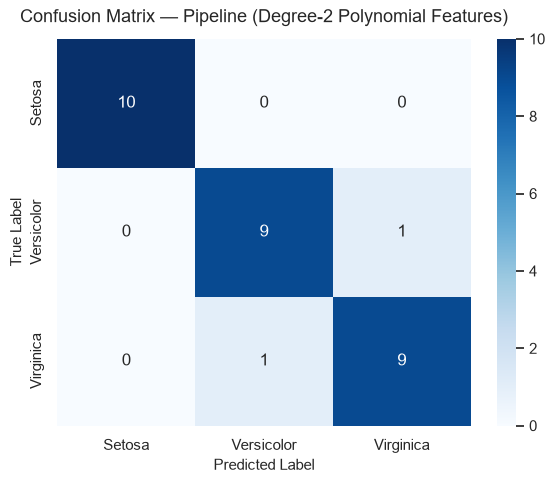


--- Pipeline vs Manual Feature Engineering ---
Manual FE : Hand-crafted domain features (ratio, area, sum, difference)
            Interpretable, requires domain knowledge
Pipeline  : Automated polynomial expansion — systematic but less interpretable
            Production-safe, prevents data leakage, GridSearch-compatible

Both approaches aim for the same goal: giving the model more informative inputs.


In [14]:
# INTERVIEW NOTE: Always split BEFORE any fitting.
# If you scale the full dataset first, test statistics leak into training.
# The Pipeline prevents this automatically.

# 80% training, 20% testing, stratified to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,           # Raw feature matrix (4 features)
    y,           # Target labels
    test_size=0.2,
    random_state=42,
    stratify=y   # Ensures each class appears proportionally in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# ----------------------------------------------------------------
# BUILD THE PIPELINE
# ----------------------------------------------------------------

pipeline = Pipeline([
    # Step 1: Standardize features to zero mean, unit variance
    ('scaler', StandardScaler()),

    # Step 2: Generate polynomial + interaction features up to degree 2
    # degree=2 creates: original features + squares + cross-products
    # include_bias=False excludes the constant '1' column (LogisticRegression adds its own)
    # INTERVIEW NOTE: With 4 input features and degree=2,
    # PolynomialFeatures generates 14 features.
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),

    # Step 3: Logistic Regression classifier
    # max_iter=300 ensures convergence on polynomial-expanded data
    ('model', LogisticRegression(max_iter=300, random_state=42))
])

# Fit: scaler fits on X_train → poly fits on scaled X_train → LR fits on poly features
pipeline.fit(X_train, y_train)

# Predict: same transformation chain applied to X_test
y_pred = pipeline.predict(X_test)

# ----------------------------------------------------------------
# EVALUATION
# ----------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("PIPELINE EVALUATION RESULTS")
print("=" * 60)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

print("\n--- Classification Report ---")
target_names = ['Setosa', 'Versicolor', 'Virginica']
print(classification_report(y_test, y_pred, target_names=target_names))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax
)
ax.set_title('Confusion Matrix — Pipeline (Degree-2 Polynomial Features)', fontsize=13, pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# COMPARISON WITH MANUAL ENGINEERING
# ----------------------------------------------------------------
print("\n--- Pipeline vs Manual Feature Engineering ---")
print("Manual FE : Hand-crafted domain features (ratio, area, sum, difference)")
print("            Interpretable, requires domain knowledge")
print("Pipeline  : Automated polynomial expansion — systematic but less interpretable")
print("            Production-safe, prevents data leakage, GridSearch-compatible")
print(f"\nBoth approaches aim for the same goal: giving the model more informative inputs.")

## Cell 11 — Visualizations: Original vs Engineered Features

**WHY:** A picture is worth a thousand confusion matrices. Visualizing feature space helps us understand class separability intuitively — why engineered features help models draw better boundaries.

**WHAT:** We create two scatter plots. Plot 1 shows the original raw features (sepal length vs sepal width). Plot 2 shows two powerful engineered features (petal area approximation vs petal-to-sepal ratio). Students should notice that engineered features produce much cleaner cluster separation.

**Expected Output:** Two side-by-side scatter plots with color-coded species, titles, axis labels, and legends.

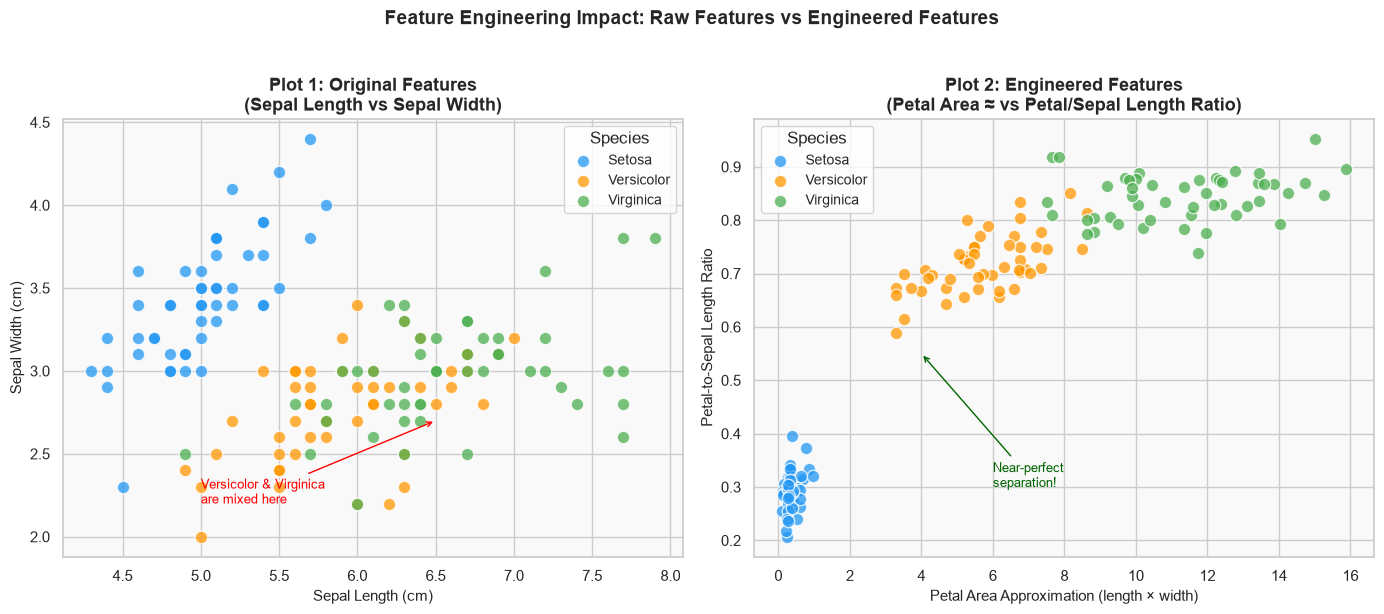


--- What You Should Observe ---
Plot 1 (Raw): Versicolor and Virginica clusters overlap significantly.
              A linear classifier will struggle to separate them.

Plot 2 (Engineered): All three species form tight, well-separated clusters.
              A simple classifier achieves near-perfect accuracy here.

INSIGHT: Feature engineering transformed a hard classification problem
         into a trivially separable one — without changing the model at all.


In [15]:
# Prepare the full engineered DataFrame with species labels for visualization
viz_df = X_engineered.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----------------------------------------------------------------
# PLOT 1: Original Features — Sepal Length vs Sepal Width
# ----------------------------------------------------------------
# This pair is notoriously overlapping for Versicolor and Virginica

species_colors = {'Setosa': '#2196F3', 'Versicolor': '#FF9800', 'Virginica': '#4CAF50'}

for species, grp in viz_df.groupby('species_name'):
    axes[0].scatter(
        grp['sepal length (cm)'],
        grp['sepal width (cm)'],
        label=species,
        color=species_colors[species],
        alpha=0.75,
        edgecolors='white',
        s=80
    )

axes[0].set_title('Plot 1: Original Features\n(Sepal Length vs Sepal Width)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=11)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=11)
axes[0].legend(title='Species', fontsize=10)
axes[0].set_facecolor('#f9f9f9')

# Annotation explaining the problem with raw features
axes[0].annotate(
    'Versicolor & Virginica\nare mixed here',
    xy=(6.5, 2.7), xytext=(5.0, 2.2),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9
)

# ----------------------------------------------------------------
# PLOT 2: Engineered Features — Petal Area vs Petal-to-Sepal Ratio
# ----------------------------------------------------------------
# These engineered features produce near-perfect class separation

for species, grp in viz_df.groupby('species_name'):
    axes[1].scatter(
        grp['petal_area_approx'],
        grp['petal_to_sepal_length_ratio'],
        label=species,
        color=species_colors[species],
        alpha=0.75,
        edgecolors='white',
        s=80
    )

axes[1].set_title('Plot 2: Engineered Features\n(Petal Area ≈ vs Petal/Sepal Length Ratio)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Area Approximation (length × width)', fontsize=11)
axes[1].set_ylabel('Petal-to-Sepal Length Ratio', fontsize=11)
axes[1].legend(title='Species', fontsize=10)
axes[1].set_facecolor('#f9f9f9')

axes[1].annotate(
    'Near-perfect\nseparation!',
    xy=(4.0, 0.55), xytext=(6.0, 0.3),
    arrowprops=dict(arrowstyle='->', color='darkgreen'),
    color='darkgreen', fontsize=9
)

plt.suptitle(
    'Feature Engineering Impact: Raw Features vs Engineered Features',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("\n--- What You Should Observe ---")
print("Plot 1 (Raw): Versicolor and Virginica clusters overlap significantly.")
print("              A linear classifier will struggle to separate them.")
print()
print("Plot 2 (Engineered): All three species form tight, well-separated clusters.")
print("              A simple classifier achieves near-perfect accuracy here.")
print()
print("INSIGHT: Feature engineering transformed a hard classification problem")
print("         into a trivially separable one — without changing the model at all.")

# Part 4: Hyperparameter Discussion

---

### Key Hyperparameters in Our Pipeline

#### `degree` in PolynomialFeatures

Controls how many higher-order terms are generated. With 4 input features:

| Degree | Number of Output Features | Example Terms |
|---|---|---|
| 1 | 4 | x₁, x₂, x₃, x₄ |
| 2 | 14 | x₁², x₁x₂, x₂², ... |
| 3 | 34 | x₁³, x₁²x₂, x₁x₂x₃, ... |

Higher degree = more expressive features, but also more risk of overfitting.

---

#### `include_bias` in PolynomialFeatures

- `True`: Adds a column of all 1s (the bias/intercept term)
- `False` (recommended with `LogisticRegression`): The model's own `fit_intercept=True` handles this
- Setting `include_bias=False` avoids redundancy and keeps the feature matrix clean

---

#### `random_state` in `train_test_split` and `LogisticRegression`

Fixes the random seed so results are identical on every run. Always set this when submitting code for review or publishing results.

---

#### `test_size` in `train_test_split`

| Split Ratio | Use Case |
|---|---|
| 80/20 | Default for medium datasets; sufficient training data |
| 70/30 | When test set evaluation needs more stability |
| 90/10 | Very small datasets where training data is precious |

---

### Underfitting vs Overfitting

- **Underfitting (degree=1):** Model is too simple — high bias, low variance. Misses patterns even in training data.
- **Just Right (degree=2):** Balances complexity and generalization. Usually the sweet spot for Iris.
- **Overfitting (degree≥3):** Model memorizes training data — low training error, high test error. Fails on new samples.

> **Analogy:** Degree 1 is like memorizing one formula for every type of math problem. Degree 3+ is like memorizing every question from the textbook — useless on the exam.

---

## Cell 13 — Hyperparameter Experiment: Polynomial Degree Comparison

**WHY:** The degree hyperparameter in PolynomialFeatures has an enormous impact on model complexity and generalization. We need empirical evidence of this tradeoff.

**WHAT:** We train three Pipelines with degree = 1, 2, and 3 respectively. We compare their training accuracy, test accuracy, and the number of features generated. A summary table is printed and a bar chart is plotted.

**Expected Output:** A comparison table showing accuracy changes across degrees, and a grouped bar chart. Degree=2 should give the best test accuracy; degree=3 may show a slight drop due to overfitting.

POLYNOMIAL DEGREE COMPARISON TABLE


,Features Generated,Train Accuracy (%),Test Accuracy (%)
Degree,,,
1,4,95.80,93.33
2,14,98.32,93.33
3,34,98.32,93.33


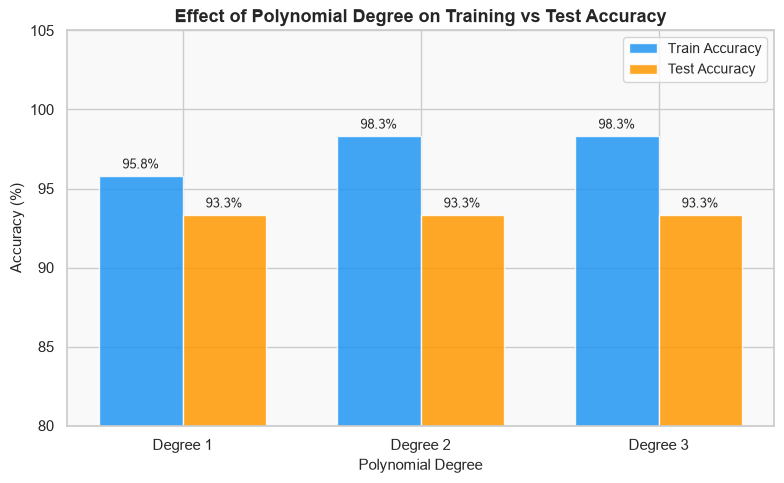


--- Analysis ---
Degree 1 : Fewest features, may underfit complex boundaries.
Degree 2 : Sweet spot — captures interactions without overfitting.
Degree 3 : More features (risk of overfitting on small datasets).
           If test acc drops while train acc rises → classic overfitting signal.


In [16]:
# Use the same train/test split from Cell 10 for a fair comparison
# (X_train, X_test, y_train, y_test already defined above)

degrees = [1, 2, 3]
results = []

for deg in degrees:
    # Build a pipeline for each degree
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        # INTERVIEW NOTE: Increasing C (regularization inverse) allows more complexity.
        # We keep it at default (C=1.0) for a fair comparison across degrees.
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])

    # Fit on training data
    pipe.fit(X_train, y_train)

    # Compute number of features after polynomial expansion
    n_features_out = pipe.named_steps['poly'].n_output_features_

    # Training accuracy — how well the model fits its own training data
    train_acc = accuracy_score(y_train, pipe.predict(X_train))

    # Test accuracy — the metric that actually matters
    test_acc = accuracy_score(y_test, pipe.predict(X_test))

    results.append({
        'Degree': deg,
        'Features Generated': n_features_out,
        'Train Accuracy (%)': round(train_acc * 100, 2),
        'Test Accuracy (%)': round(test_acc * 100, 2)
    })

results_df = pd.DataFrame(results)

print("=" * 60)
print("POLYNOMIAL DEGREE COMPARISON TABLE")
print("=" * 60)
display(results_df.set_index('Degree'))

# ----------------------------------------------------------------
# VISUALIZATION: Training vs Test Accuracy per Degree
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(degrees))
bar_width = 0.35

bars_train = ax.bar(
    x - bar_width / 2,
    results_df['Train Accuracy (%)'],
    width=bar_width,
    label='Train Accuracy',
    color='#2196F3',
    alpha=0.85,
    edgecolor='white'
)

bars_test = ax.bar(
    x + bar_width / 2,
    results_df['Test Accuracy (%)'],
    width=bar_width,
    label='Test Accuracy',
    color='#FF9800',
    alpha=0.85,
    edgecolor='white'
)

# Annotate bars with accuracy values
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Effect of Polynomial Degree on Training vs Test Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Polynomial Degree', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f'Degree {d}' for d in degrees])
ax.set_ylim(80, 105)
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

print("\n--- Analysis ---")
print("Degree 1 : Fewest features, may underfit complex boundaries.")
print("Degree 2 : Sweet spot — captures interactions without overfitting.")
print("Degree 3 : More features (risk of overfitting on small datasets).")
print("           If test acc drops while train acc rises → classic overfitting signal.")

# INTERVIEW NOTE: On small datasets like Iris, overfitting from degree=3
# might be subtle. On real production datasets it becomes severe quickly.

# Part 5: Interview Corner

---

These are the most commonly asked Feature Engineering questions in ML interviews at product companies and research labs.

---

### Q1. What is Feature Engineering?

Feature Engineering is the process of using domain knowledge and mathematical transformations to create, modify, or select input variables that make ML algorithms perform better. It bridges the gap between raw data and what a model can effectively learn.

---

### Q2. Why is Feature Engineering Important?

ML models are only as good as the information fed to them. Well-engineered features encode domain knowledge directly into the data, allowing even simple models to achieve high performance. It often matters more than the choice of algorithm.

---

### Q3. Difference Between Feature Engineering and Feature Selection?

- **Feature Engineering** creates *new* features from existing ones (e.g., computing petal area from length × width)
- **Feature Selection** chooses the *best subset* of existing features to use (e.g., dropping features with low variance)

One creates; the other curates.

---

### Q4. Why Do We Scale Features?

Features measured in different units (cm vs kg vs %) have different numerical ranges. Without scaling, a model treats large-valued features as more important, even if they carry less signal. Scaling ensures all features compete on equal mathematical footing, which is essential for gradient descent, SVMs, KNN, and regularized models.

---

### Q5. What Are Interaction Features?

Interaction features are created by multiplying two or more features together. They capture combined effects — for example, `petal_length × petal_width` captures petal size as an area, which is more meaningful than either dimension alone. Interaction features allow linear models to capture non-linear relationships.

---

### Q6. What Are Polynomial Features?

Polynomial features are higher-degree transformations of existing features. For a feature `x`, degree-2 polynomial features include `x²`. For two features `x` and `z`, they include `x²`, `xz`, and `z²`. This lets a linear model fit curved decision boundaries, effectively becoming a non-linear classifier in the original feature space.

---

### Q7. Can Feature Engineering Reduce Bias?

Yes. Bias (underfitting) occurs when a model is too simple to capture the true underlying patterns. Adding polynomial features, interaction terms, or domain-derived features gives the model richer inputs, reducing bias by enabling it to fit more complex relationships.

---

### Q8. Can Feature Engineering Cause Overfitting?

Absolutely. Adding too many features — especially high-degree polynomial expansions — increases model complexity. With a small dataset, the model may memorize training examples rather than learning general patterns. This is why we regularize (L1/L2) and validate on held-out test sets after every round of feature engineering.

---

# Key Takeaways

---

- **Feature Engineering is often more impactful than model selection.** A simple Logistic Regression with well-crafted features can outperform a complex neural network on poorly prepared data — the quality of your input representation determines the ceiling of model performance.

- **Always scale your features before applying distance-based or gradient-based algorithms.** StandardScaler (zero mean, unit variance) and MinMaxScaler ([0,1] range) ensure that no feature dominates due to its measurement units rather than its true predictive power.

- **Handcrafted features encode domain knowledge; polynomial features encode mathematical interactions.** Domain features (ratios, areas, differences) are interpretable and generalizable. Polynomial features are systematic but grow exponentially and require regularization to avoid overfitting.

- **More features do not guarantee better performance.** Adding features increases model complexity, which can hurt generalization on small datasets. Always validate on a held-out test set and monitor both training and test accuracy to detect the onset of overfitting.

- **In production, always use Scikit-learn Pipelines for feature engineering.** Pipelines prevent data leakage, ensure consistent preprocessing between training and inference, are compatible with cross-validation and hyperparameter search, and can be serialized into a single deployable object.

---

*End of Notebook — Feature Engineering in Machine Learning*